<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Data-set:-Quotes-on-Deribit-option-on-BTC-USD-on-April-26,-2023,-between-20:05-and-20:06" data-toc-modified-id="Data-set:-Quotes-on-Deribit-option-on-BTC-USD-on-April-26,-2023,-between-20:05-and-20:06-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Data set: Quotes on Deribit option on BTC-USD on April 26, 2023, between 20:05 and 20:06</a></span><ul class="toc-item"><li><span><a href="#Getting-data" data-toc-modified-id="Getting-data-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Getting data</a></span></li><li><span><a href="#Putting-colors-on-Bid,-Ask,-Call,-Put" data-toc-modified-id="Putting-colors-on-Bid,-Ask,-Call,-Put-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>Putting colors on Bid, Ask, Call, Put</a></span></li></ul></li><li><span><a href="#What-is-the-forward?" data-toc-modified-id="What-is-the-forward?-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>What is the forward?</a></span><ul class="toc-item"><li><span><a href="#We-gather-data-by-strikes" data-toc-modified-id="We-gather-data-by-strikes-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>We gather data by strikes</a></span></li><li><span><a href="#We-compute-the-best-bid-and-the-best-ask" data-toc-modified-id="We-compute-the-best-bid-and-the-best-ask-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>We compute the best bid and the best ask</a></span></li></ul></li></ul></div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Data set: Quotes on Deribit option on BTC-USD on April 26, 2023, between 20:05 and 20:06

## Getting data

In [6]:
df = pd.read_csv('DataCallPut-bidask-deribit-2604.csv') 
df

,id,date,type,price,amount,strike,expiry,option_type
0,16306,2023-04-26 20:05:00.110,a,0.0315,3.8,28500.0,12MAY23,C
1,16304,2023-04-26 20:05:00.110,a,0.0305,23.0,28500.0,12MAY23,C
2,16302,2023-04-26 20:05:00.110,b,0.0275,25.8,28500.0,12MAY23,C
3,16303,2023-04-26 20:05:00.110,b,0.0265,2.7,28500.0,12MAY23,C
4,16305,2023-04-26 20:05:00.110,a,0.0310,4.0,28500.0,12MAY23,C
...,...,...,...,...,...,...,...,...
173,18767,2023-04-26 20:05:52.953,b,0.0420,27.1,27500.0,12MAY23,P
174,18769,2023-04-26 20:05:52.953,a,0.0455,7.5,27500.0,12MAY23,P
175,18768,2023-04-26 20:05:52.953,a,0.0450,29.5,27500.0,12MAY23,P
176,18766,2023-04-26 20:05:52.953,b,0.0425,16.9,27500.0,12MAY23,P


## Putting colors on Bid, Ask, Call, Put

Number of Call data= 92
Number of Put data= 86


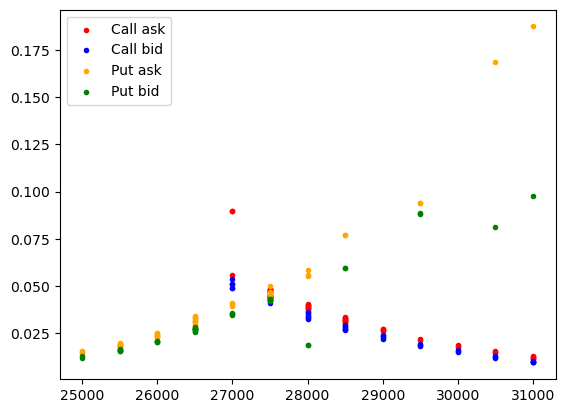

In [7]:
call_ask_strike=df[(df.type=="a") & (df.option_type=="C")].strike
call_ask_price=df[(df.type=="a") & (df.option_type=="C")].price
plt.scatter(call_ask_strike, call_ask_price, color="red", marker=".", label="Call ask")

call_bid_strike=df[(df.type=="b") & (df.option_type=="C")].strike
call_bid_price=df[(df.type=="b") & (df.option_type=="C")].price
plt.scatter(call_bid_strike, call_bid_price, color="blue", marker=".", label="Call bid")

put_ask_strike=df[(df.type=="a") & (df.option_type=="P")].strike
put_ask_price=df[(df.type=="a") & (df.option_type=="P")].price
plt.scatter(put_ask_strike, put_ask_price, color="orange", marker=".", label="Put ask")

put_bid_strike=df[(df.type=="b") & (df.option_type=="P")].strike
put_bid_price=df[(df.type=="b") & (df.option_type=="P")].price
plt.scatter(put_bid_strike, put_bid_price, color="green", marker=".", label="Put bid")

plt.legend()
print ("Number of Call data=",np.size(call_ask_price)+np.size(call_bid_price))
print ("Number of Put data=",np.size(put_ask_price)+np.size(put_bid_price))

# What is the forward?


## We gather data by strikes

In [8]:
list_of_strikes=[]
for strikes in df.strike:
    if strikes not in list_of_strikes:
        list_of_strikes.append(strikes)
list_of_strikes=np.sort(list_of_strikes) 
print(list_of_strikes)

[25000. 25500. 26000. 26500. 27000. 27500. 28000. 28500. 29000. 29500.
 30000. 30500. 31000.]


## We compute the best bid and the best ask

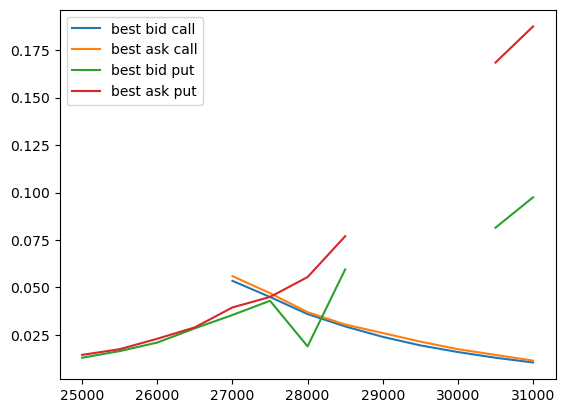

In [5]:
best_bid_call=[]
best_ask_call=[]
best_bid_put=[]
best_ask_put=[]
for strikes in list_of_strikes:
    best_bid_call=np.append(best_bid_call, np.max(df[(df.type=="b") & (df.option_type=="C") & (df.strike==strikes)].price))
    best_ask_call=np.append(best_ask_call, np.min(df[(df.type=="a") & (df.option_type=="C") & (df.strike==strikes)].price))
    best_bid_put=np.append(best_bid_put, np.max(df[(df.type=="b") & (df.option_type=="P") & (df.strike==strikes)].price))
    best_ask_put=np.append(best_ask_put, np.min(df[(df.type=="a") & (df.option_type=="P") & (df.strike==strikes)].price))

plt.plot(list_of_strikes, best_bid_call, label="best bid call")
plt.plot(list_of_strikes, best_ask_call, label="best ask call")
plt.plot(list_of_strikes, best_bid_put, label="best bid put")
plt.plot(list_of_strikes, best_ask_put, label="best ask put")
plt.legend()